# Loading Responses

In [1]:
options(warn=1)
if(!require('lme4')) {
    install.packages('lme4', repos='https://cloud.r-project.org')
    library('lme4')
}
if(!require('readr')) {
    install.packages('readr', repos='https://cloud.r-project.org')
    library('readr')
}
if(!require('marginaleffects')) {
    install.packages('marginaleffects', repos='https://cloud.r-project.org')
    library('marginaleffects')
}
if(!require('car')) {
    install.packages('car', repos='https://cloud.r-project.org')
    library('car')
}
if(!require('ggplot2')) {
    install.packages('ggplot2', repos='https://cloud.r-project.org')
    library('ggplot2')
}
if(!require('parameters')) {
  install.packages('parameters', repos='https://cloud.r-project.org')
  library('parameters')
}
if(!require('performance')) {
  install.packages('performance', repos='https://cloud.r-project.org')
  library('performance')
}
df <- read_csv("../output/result_1763865486_20250506_20250506T.csv", na = "empty", col_select = c("Accuracy", "Group", "GroupKind", "Angle", "Proximity", "n_candidates", "Actor", "Candidates", "Stimulus_ID", "Prompt_ID", "Participant_ID", "list_id", "Run_ID", "Part", "Accuracy_head", "Wrongness", "Wrongness_head"), col_types = cols(
    Accuracy = col_logical(),
    Group = col_factor(),
    GroupKind = col_factor(),
    Angle = col_factor(),
    Proximity = col_integer(),
    n_candidates = col_integer(),
    Actor = col_factor(c('X', 'Y')),
    Candidates = col_factor(),
    Stimulus_ID = col_factor(),
    Prompt_ID = col_factor(),
    Participant_ID = col_factor(),
    list_id = col_factor(),
    Run_ID = col_character(),
    Part = col_character(),
    Accuracy_head = col_logical(),
    Wrongness = col_double(),
    Wrongness_head = col_double()
),show_col_types = TRUE)
df <- df[df$Group == "Humans" & df$list_id != -1 & df$Part != "p0", ]
df$offset_logit <- qlogis((df$n_candidates + 1) / (3 * df$n_candidates))
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))
df$n_candidates_c <- as.numeric(scale(df$n_candidates, scale = FALSE))
df$Proximity_c    <- as.numeric(scale(df$Proximity, scale = FALSE))

Loading required package: lme4

Loading required package: Matrix

Loading required package: readr

Loading required package: marginaleffects

Loading required package: car

Loading required package: carData

Loading required package: ggplot2

Loading required package: parameters

Loading required package: performance

Rows: 155393 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Run_ID, Part
dbl (2): Wrongness, Wrongness_head
int (2): Proximity, n_candidates
lgl (2): Accuracy, Accuracy_head
fct (9): Stimulus_ID, Prompt_ID, Participant_ID, Group, GroupKind, Angle, Ac...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 26.1

Matrix products: default
BLAS/LAPACK: /Users/zory/miniforge3/envs/py310/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] performance_0.14.0     parameters_0.28.3      ggplot2_3.5.1         
[4] car_3.1-3              carData_3.0-5          marginaleffects_0.25.1
[7] readr_2.1.5            lme4_1.1-35.5          Matrix_1.6-5          

loaded via a namespace (and not attached):
 [1] generics_0.1.4     lattice_0.22-6     hms_1.1.3          digest_0.6.37     
 [5] magrittr_2.0.3     evaluate_0.22      grid_4.3.3         estimability_1.5.1
 [9] pbdZMQ_0.3-14      mvtnorm_1.3-3      fastmap_1.2.0      jsonlite_2.0.0    
[13] backports_1.5.0    Formula_1

# Random effect structure

In [3]:
model1 <- glmer(cbind(Wrongness, n_candidates - 1 - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Participant_ID) + (1 | Actor:Candidates), data = df, family = binomial, control = strict_control)
model2 <- glmer(cbind(Wrongness, n_candidates - 1 - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Actor:Candidates), data = df, family = binomial, control = strict_control)
model3 <- glmer(cbind(Wrongness, n_candidates - 1 - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Participant_ID), data = df, family = binomial, control = strict_control)
model4 <- glmer(cbind(Wrongness, n_candidates - 1 - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID), data = df, family = binomial, control = strict_control)
compare_performance(model1, model2, model3, model4, rank = TRUE)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

Some of the nested models seem to be identical and probably only vary in
  their random effects.

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

Following indices with missing values are not used for ranking: Sigma,
  Log_loss



Name,Model,R2_conditional,R2_marginal,ICC,RMSE,Sigma,Log_loss,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
model3,glmerMod,0.6476777,0.4682308,0.3374526,0.1578189,1,NA,0.720931239,0.722958547,0.767050305,0.8571429
model1,glmerMod,0.6476752,0.4682343,0.3374435,0.1578195,1,NA,0.265189282,0.263017210,0.014181348,0.5340451
model4,glmerMod,0.6328783,0.4766364,0.2985341,0.1622368,1,NA,0.010146810,0.010281078,0.214796895,0.1849398
model2,glmerMod,0.6328761,0.4766368,0.2985294,0.1622370,1,NA,0.003732668,0.003743164,0.003971452,0.1428571


In [53]:
isSingular(model1)
isSingular(model2)
isSingular(model3)
isSingular(model4)

[1] TRUE

[1] TRUE

[1] FALSE

[1] FALSE

In [54]:
anova(model3, model4)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model4,14,1412.628,1496.363,-692.3142,1384.628,NA,NA,NA
model3,15,1404.102,1493.817,-687.0508,1374.102,10.52677,1,0.001176578


In [42]:
model <- model3

# Main Effects

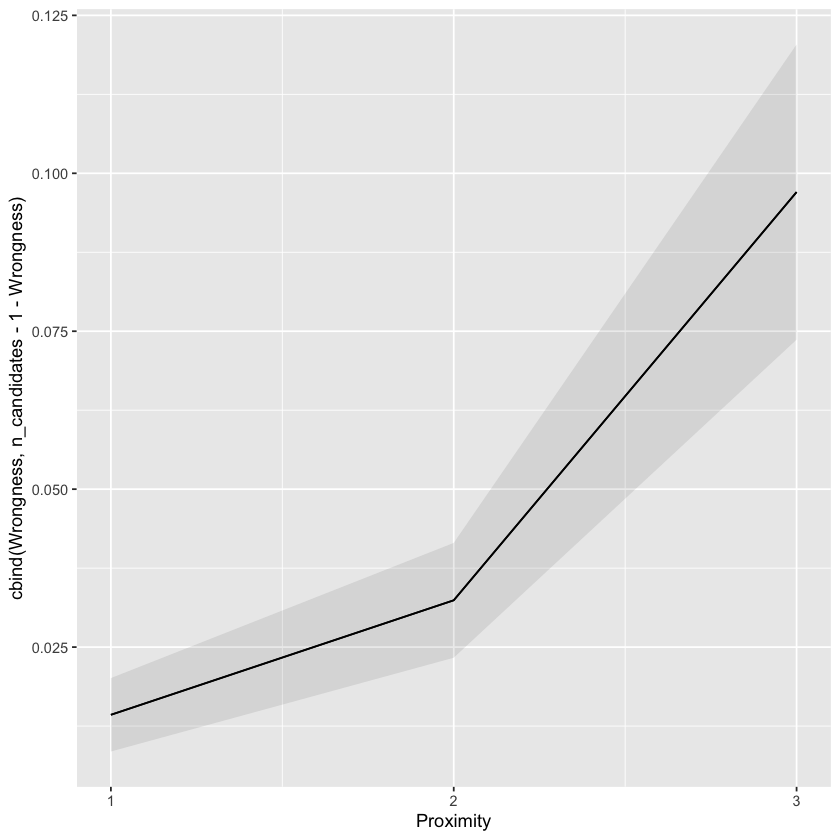

In [22]:
plot_predictions(model, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))

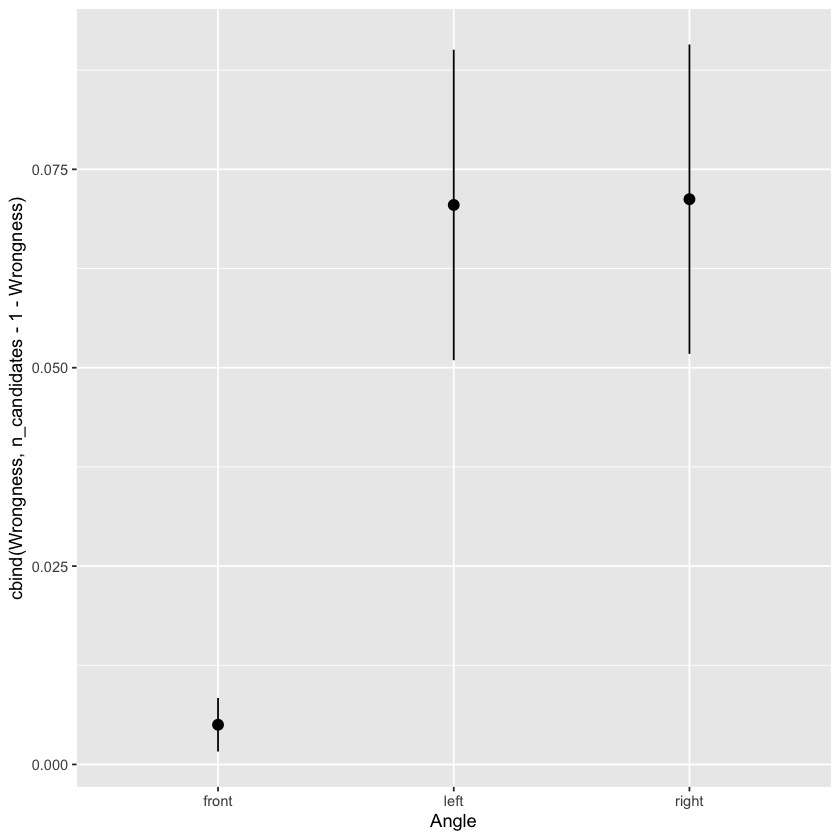

In [23]:
plot_predictions(model, by = c("Angle"))

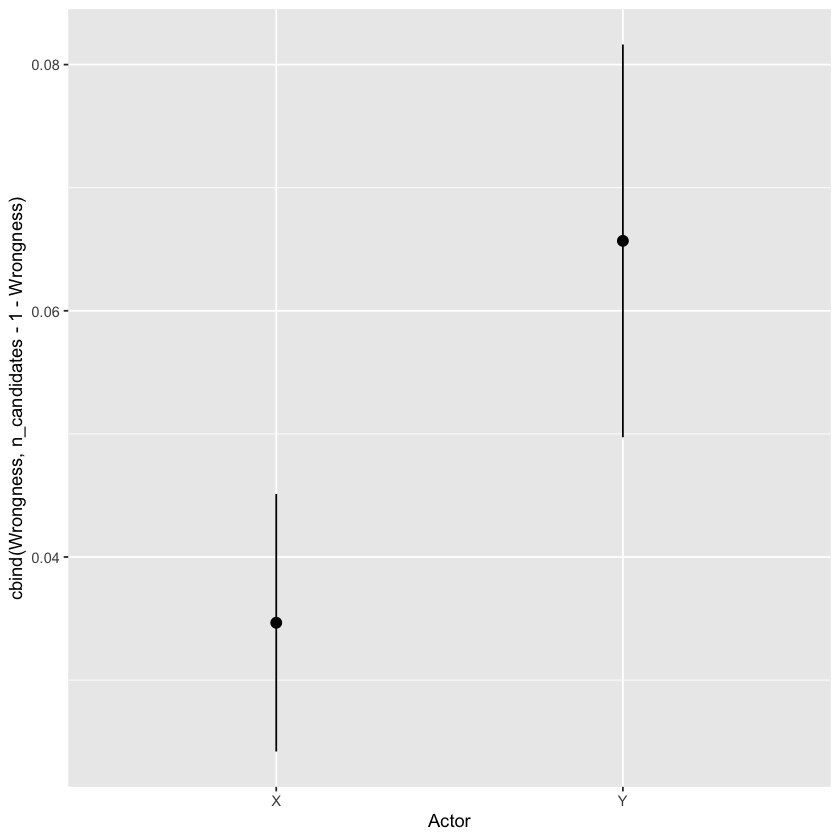

In [24]:
plot_predictions(model, by = c("Actor"))

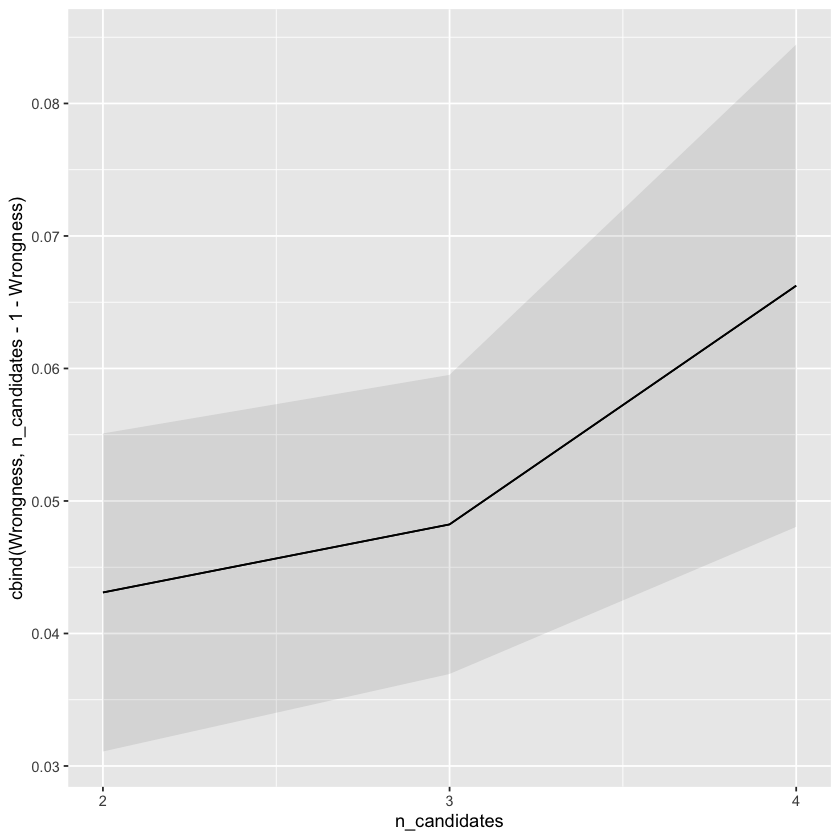

In [25]:
plot_predictions(model, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))

In [26]:
avg_slopes(model, variables = "Proximity_c")
avg_slopes(model, variables = "n_candidates_c")
avg_comparisons(model, variables = "Angle")
avg_comparisons(model, variables = "Actor")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity_c,dY/dX,0.05120069,0.007708501,6.642107,3.09231e-11,34.91252,0.0360923,0.06630907,0.002931395,0.00293125,0.002931323


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates_c,dY/dX,0.01236202,0.004569347,2.705424,0.006821716,7.19565,0.003406268,0.02131778,0.002931208,0.002931438,0.002931323


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.06169625,0.009248986,6.670597,2.547652e-11,35.19204,0.04356858,0.07982393
Angle,right - front,0.06608257,0.009956175,6.637345,3.193830e-11,34.86592,0.04656882,0.08559631


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actor,Y - X,0.03048127,0.007536847,4.044301,5.247955e-05,14.21789,0.01570933,0.04525322,0.001388944,0.002931323,0.002931323


Conclusion: Proximity, View and Choice effect. Actor difference.

# Interpret interactions

In [43]:
model_null <- glmer(cbind(Wrongness, n_candidates - 1 - Wrongness) ~ Proximity_c + Angle + n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID), data = df, family = binomial, control = strict_control)
anova(model_null, model)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_null,7,1430.322,1472.189,-708.1609,1416.322,NA,NA,NA
model,15,1404.102,1493.817,-687.0508,1374.102,42.2203,8,1.23123e-06


We find interactions! Now we need to unpack them.

### Proximity effect

In [44]:
avg_slopes(model, variables = "Proximity_c", by = "Angle")
avg_slopes(model, variables = "Proximity_c", by = "Angle", hypothesis = ~ pairwise)

term,contrast,Angle,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity_c,dY/dX,front,0.002581386,0.002520518,1.024149,3.057650e-01,1.709505,-0.002358739,0.007521511
Proximity_c,dY/dX,left,0.075045043,0.016167228,4.641800,3.453869e-06,18.143355,0.043357858,0.106732228
Proximity_c,dY/dX,right,0.077368227,0.015507154,4.989196,6.063120e-07,20.653436,0.046974763,0.107761691


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(left) - (front),0.072463657,0.01628072,4.450888,8.551602e-06,16.8353739,0.04055403,0.10437328
(right) - (front),0.074786842,0.01564637,4.779820,1.754519e-06,19.1204929,0.04412052,0.10545316
(right) - (left),0.002323184,0.02170592,0.107030,9.147652e-01,0.1285266,-0.04021964,0.04486601


### Choice effect

In [45]:
avg_slopes(model, variables = "n_candidates_c", by = "Proximity")

term,contrast,Proximity,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates_c,dY/dX,1,0.017641319,0.004620634,3.81794335,1.345688e-04,12.8593683,0.008585043,0.02669759
n_candidates_c,dY/dX,2,0.020828101,0.003707533,5.61777837,1.934284e-08,25.6236252,0.013561469,0.02809473
n_candidates_c,dY/dX,3,-0.001020159,0.010570158,-0.09651312,9.231131e-01,0.1154207,-0.021737287,0.01969697


In [46]:
avg_slopes(model, variables = "n_candidates_c", by = "Proximity", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(2) - (1),0.003186783,0.003059532,1.041592,0.29760110,1.748548,-0.00280979,0.009183355
(3) - (1),-0.018661478,0.012302175,-1.516925,0.12928561,2.951366,-0.04277330,0.005450343
(3) - (2),-0.021848260,0.009793740,-2.230839,0.02569178,5.282549,-0.04104364,-0.002652882


### View effect

# Report

In [48]:
summary(model)


Correlation matrix not shown by default, as p = 13 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, n_candidates - 1 - Wrongness) ~ Proximity_c *  
    Angle * n_candidates_c + Actor + offset(offset_logit) + (1 |  
    Stimulus_ID) + (1 | Participant_ID)
   Data: df
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
  1404.1   1493.8   -687.1   1374.1     2910 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.1329 -0.2590 -0.0996 -0.0532 12.6318 

Random effects:
 Groups         Name        Variance Std.Dev.
 Stimulus_ID    (Intercept) 0.8509   0.9224  
 Participant_ID (Intercept) 0.2091   0.4573  
Number of obs: 2925, groups:  Stimulus_ID, 900; Participant_ID, 65

Fixed effects:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                            -6.0001     0.4473 -13.413  < 2e-16 ***
Proximity_c                             0.1998     0.4957   0.403  0.

In [49]:
model_parameters(model)

Parameter,Coefficient,SE,CI,CI_low,CI_high,z,df_error,p,Effects,Group
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
(Intercept),-6.0001140,0.4473428,0.95,-6.8768897,-5.1233383,-13.4127891,Inf,5.088837e-41,fixed,
Proximity_c,0.1997914,0.4957470,0.95,-0.7718549,1.1714378,0.4030109,Inf,6.869402e-01,fixed,
Angleleft,2.2880107,0.4573503,0.95,1.3916206,3.1844007,5.0027536,Inf,5.651717e-07,fixed,
Angleright,2.3690936,0.4516776,0.95,1.4838217,3.2543654,5.2450983,Inf,1.561990e-07,fixed,
n_candidates_c,0.4048582,0.4160804,0.95,-0.4106443,1.2203608,0.9730290,Inf,3.305389e-01,fixed,
ActorY,0.7484559,0.1763777,0.95,0.4027619,1.0941499,4.2434827,Inf,2.200773e-05,fixed,
Proximity_c:Angleleft,1.2046831,0.5496521,0.95,0.1273848,2.2819815,2.1917192,Inf,2.839979e-02,fixed,
Proximity_c:Angleright,1.2085635,0.5463871,0.95,0.1376645,2.2794625,2.2119181,Inf,2.697232e-02,fixed,
Proximity_c:n_candidates_c,0.7712576,0.4906615,0.95,-0.1904213,1.7329364,1.5718730,Inf,1.159800e-01,fixed,


In [50]:
Anova(model, type = 3)

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),179.9029123,1,5.088837e-41
Proximity_c,0.1624178,1,6.869402e-01
Angle,29.0905569,2,4.820208e-07
n_candidates_c,0.9467853,1,3.305389e-01
Actor,18.0071456,1,2.200773e-05
Proximity_c:Angle,5.3155910,2,7.010259e-02
Proximity_c:n_candidates_c,2.4707846,1,1.159800e-01
Angle:n_candidates_c,0.8945779,2,6.393591e-01
Proximity_c:Angle:n_candidates_c,9.2771456,2,9.671491e-03


In [51]:
vc_list <- lapply(VarCorr(model), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(model)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-6.0001140,0.4473428,-13.4127891,0.00000000000000000000000000000000000000005088837,-6.8769058,-5.1233222,2.08562,-2.87689703
Proximity_c,0.1997914,0.4957470,0.4030109,0.68694022055851688968175494665047153830528259277,-0.7718727,1.1714556,2.08562,0.09579475
Angleleft,2.2880107,0.4573503,5.0027536,0.00000056517168923149443223228173896477422033513,1.3916041,3.1844172,2.08562,1.09704101
Angleright,2.3690936,0.4516776,5.2450983,0.00000015619900028608797986490186460173390514683,1.4838054,3.2543817,2.08562,1.13591813
n_candidates_c,0.4048582,0.4160804,0.9730290,0.33053891226138898407072019836050458252429962158,-0.4106593,1.2203757,2.08562,0.19411889
ActorY,0.7484559,0.1763777,4.2434827,0.00002200773295675808677524312728657207571814070,0.4027555,1.0941562,2.08562,0.35886493
Proximity_c:Angleleft,1.2046831,0.5496521,2.1917192,0.02839978616212957690523310816388402599841356277,0.1273650,2.2820013,2.08562,0.57761390
Proximity_c:Angleright,1.2085635,0.5463871,2.2119181,0.02697232492649619464697430260002875002101063728,0.1376448,2.2794822,2.08562,0.57947444
Proximity_c:n_candidates_c,0.7712576,0.4906615,1.5718730,0.11598001530044942108954586501567973755300045013,-0.1904390,1.7329541,2.08562,0.36979774


The below code is for generating the table in the paper.

In [52]:
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
actory_est <- res[res$term == actory_term_name, "Estimate"]
actory_se <- res[res$term == actory_term_name, "Std. Error"]
actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("Angleleft", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("Angleright", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size)),

    c("ActorY", "b", sprintf("%.7f", actory_est)),
    c("", "SE", sprintf("%.7f", actory_se)),
    c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

0.8508528
0.2090899
NA
2.0856200
-6.0001140
0.4473428
2.2880107
0.4573503
0.0000006
1.0970410
2.3690936
0.4516776
0.0000002
1.1359181
0.1997914
0.4957470
0.6869402
0.0957948
0.4048582
0.4160804
0.3305389
0.1941189
0.7484559
0.1763777
0.0000220
0.3588649
